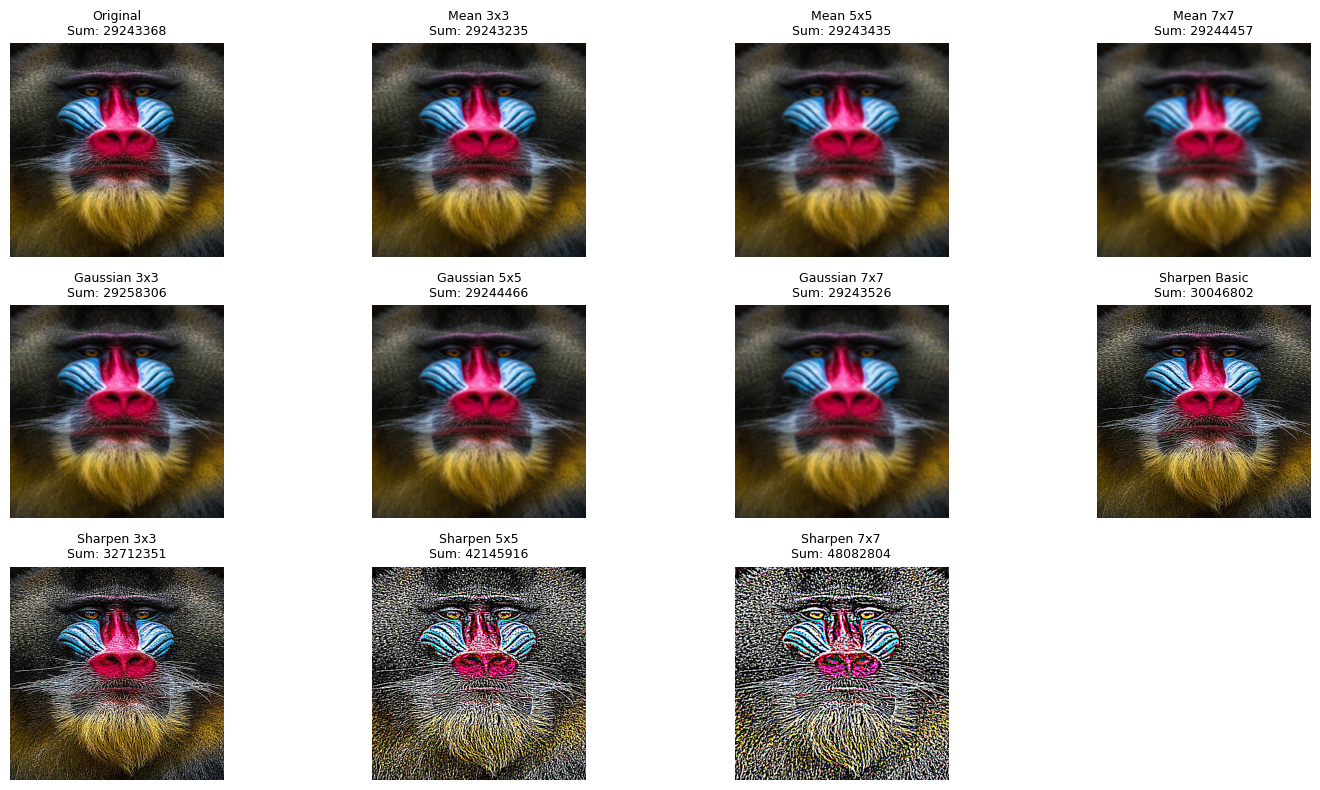

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Không đọc được ảnh tại: {path}")
    return img
# 2. 
def mean_filter(img, ksize):
    return cv2.blur(img, (ksize, ksize))


def gaussian_filter(img, ksize):
    return cv2.GaussianBlur(img, (ksize, ksize), 0)


def sharpen_filter(img):
    kernel = np.array([
        [0, -1, 0],
        [-1, 5,-1],
        [0, -1, 0]
    ])
    return cv2.filter2D(img, -1, kernel)

def sharpen_multi(img):
    results = []
 k3 = np.array([
        [-1, -1, -1],
        [-1,  9, -1],
        [-1, -1, -1]
    ])
    results.append(("Sharpen 3x3", cv2.filter2D(img, -1, k3)))

    # 5x5
    k5 = -1 * np.ones((5,5))
    k5[2,2] = 25
    results.append(("Sharpen 5x5", cv2.filter2D(img, -1, k5)))

    # 7x7
    k7 = -1 * np.ones((7,7))
    k7[3,3] = 49
    results.append(("Sharpen 7x7", cv2.filter2D(img, -1, k7)))

    return results

def to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



def sum_pixel(img):
    return np.sum(img)


def show_images(images, titles):
    cols = 4
    rows = int(np.ceil(len(images) / cols))

    plt.figure(figsize=(15, 8))

    for i in range(len(images)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(f"{titles[i]}\nSum: {sum_pixel(images[i])}", fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

path = "../input/lab_image.jpg"

try:
    img = load_image(path)

    img = cv2.resize(img, (400, 400))

    sizes = [3, 5, 7]

    images = []
    titles = []


    images.append(to_rgb(img))
    titles.append("Original")

    # Mean
    for k in sizes:
        m = mean_filter(img, k)
        images.append(to_rgb(m))
        titles.append(f"Mean {k}x{k}")

    # Gaussian 
    for k in sizes:
        g = gaussian_filter(img, k)
        images.append(to_rgb(g))
        titles.append(f"Gaussian {k}x{k}")

    # Sharpen 
    s = sharpen_filter(img)
    images.append(to_rgb(s))
    titles.append("Sharpen Basic")

    sharp_list = sharpen_multi(img)
    for name, im in sharp_list:
        images.append(to_rgb(im))
        titles.append(name)

    # Hiển thị
    show_images(images, titles)



except Exception as e:
    print(" Lỗi:", e)

In [13]:
print(k3)

NameError: name 'k3' is not defined